# Week 4: Data Analysis & Baseline Retrospective

**Sections:**
- §2: Baseline Retrospective (LIM-005, LIM-008 actual chunk capture)
- §3: Data Quality Diagnosis (structure, noise, LIM-001 quantification)

## 1. Setup

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

PDF_DIR = Path("../data/raw_pdfs")
CHROMA_DIR = Path("../data/chroma_db")

# Load existing vector store
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = Chroma(
    persist_directory=str(CHROMA_DIR),
    embedding_function=embeddings,
    collection_name="lg_manuals",
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

print(f"Vector store loaded: {vectorstore._collection.count()} documents")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Vector store loaded: 320 documents


---
## §2. Baseline Retrospective

Capture actual chunk text for LIM-005 and LIM-008 instances.

### §2.1 LIM-005 Instance: Category Cross-Contamination

Query: "정수기 필터 교체는 어떻게 하나요?"

Expected: waterpurifier chunks only  
Problem: airpurifier chunks appeared in top-5

In [2]:
# LIM-005: Category cross-contamination
query_lim005 = "정수기 필터 교체는 어떻게 하나요?"

results = retriever.invoke(query_lim005)

print(f"Query: {query_lim005}")
print("=" * 70)

for i, doc in enumerate(results):
    meta = doc.metadata
    category = meta.get('category', 'unknown')
    is_correct = category == 'waterpurifier'
    status = "✅" if is_correct else "❌ WRONG CATEGORY"
    
    print(f"\n[{i+1}] {status}")
    print(f"    chunk_id: {meta.get('chunk_id')}")
    print(f"    source: {meta.get('source')}")
    print(f"    category: {category}")
    print(f"    page: {meta.get('page')}")
    print(f"    --- CHUNK TEXT ---")
    print(f"    {doc.page_content[:500]}...")

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Query: 정수기 필터 교체는 어떻게 하나요?

[1] ✅
    chunk_id: waterpurifier_complex_p028_c000
    source: waterpurifier_complex.pdf
    category: waterpurifier
    page: 28
    --- CHUNK TEXT ---
    28 관리하기
• 정수 필터를 분리할 때 내부 압력에 의해 약간의 물이
알아두기
떨어질 수 있습니다. 아래에 마른 수건을 놓으세요.
물이 얼 때 물속의 미네랄이 중심축으로 모여 서로
결합하여 대부분 탄산칼슘으로 변하고 얼음 속에서
하얗게 보여요. 또한 얼음이 녹으면, 탄산칼슘만 남아
흰색 결정체가 보일 수 있어요.
정수 필터 교체하기
모델명: WD523A**, WD524A**, WD323A**,
WD520A**, WD507A**, WD508A**
주기적으로 필터 교체를 하지 않으면 정수기의 수질이
3
낮아질 수 있습니다. 솔을 이용하여 필터 체결부를 청소하세요.
• 원수 수질, 물 사용량과 직수관/출수구 살균 기능
사용량에 따라 예상 교체 주기가 달라질 수 있습니다.
• 각 필터의 교체 주기는 다음과 같습니다.
- 중금속9 흡착 필터: 6개월 (10 L/일 사용기준)
- 바이러스 클리어 필터: 12개월 (10 L/일 사용기준)
• 필터 교체 주기는 4인 가정 하루 10 L 사용을 기...

[2] ❌ WRONG CATEGORY
    chunk_id: MFL69726859_p037_c000
    source: airpurifier_complex_MFL69726859_00_190321_00.pdf
    category: airpurifier
    page: 37
    --- CHUNK TEXT ---
    필터 청소하기 필터 교체하기
1 제품의 커버를 분리하세요. 1 제품의 커버를 분리하고 필터를 교체하세요.
• 커버 분리 및 장착 방법은 필터 보호 • 커버 분리 및 필터 교체 방법은 필터
비닐과 고정 테이프 제거하기를 보호 

### §2.1.1 LIM-005 Detailed Capture

Capture the wrong chunk and expected correct chunk for presentation.

In [3]:
# Find wrong category chunks
wrong_chunks = [(i, doc) for i, doc in enumerate(results) 
                if doc.metadata.get('category') != 'waterpurifier']

if wrong_chunks:
    idx, wrong_doc = wrong_chunks[0]
    print("=" * 70)
    print("LIM-005 INSTANCE: Wrong Category Chunk")
    print("=" * 70)
    print(f"Position in results: [{idx+1}]")
    print(f"chunk_id: {wrong_doc.metadata.get('chunk_id')}")
    print(f"source: {wrong_doc.metadata.get('source')}")
    print(f"category: {wrong_doc.metadata.get('category')}")
    print(f"page: {wrong_doc.metadata.get('page')}")
    print(f"\nFULL CHUNK TEXT:")
    print("-" * 70)
    print(wrong_doc.page_content)
    print("-" * 70)
else:
    print("No wrong category chunks found (LIM-005 may be resolved?)")

LIM-005 INSTANCE: Wrong Category Chunk
Position in results: [2]
chunk_id: MFL69726859_p037_c000
source: airpurifier_complex_MFL69726859_00_190321_00.pdf
category: airpurifier
page: 37

FULL CHUNK TEXT:
----------------------------------------------------------------------
필터 청소하기 필터 교체하기
1 제품의 커버를 분리하세요. 1 제품의 커버를 분리하고 필터를 교체하세요.
• 커버 분리 및 장착 방법은 필터 보호 • 커버 분리 및 필터 교체 방법은 필터
비닐과 고정 테이프 제거하기를 보호 비닐과 고정 테이프 제거하기를
참조하세요. 참조하세요.
2 진공 청소기 또는 부드러운 솔을 이용해 • 필터를 교체할 때 주변이 오염되는 것을
토탈 알러지 집진 필터를 감싸고 있는 방지하려면 필터를 분리하기 전에 바닥에
극세필터의 먼지를 제거하세요. 신문지 등을 펼쳐 놓으세요.
2 필터 교체가 끝나면 필터 교체 알림을
해제하세요.
상부 필터 교체 알림 해제하기
청정세기 버튼과 먼지상태 버튼을 동시에 3초
이상 누르세요.
• 상태 표시부의 (상부 필터 교체 알림)이
해제되고 교체 알림 시간이 초기화됩니다.
주의
• 토탈 알러지 집진 필터와 토탈 유해가스
필터를 물로 세척하지 마십시오. 필터의 수명이
단축되는 원인이 됩니다.
• 진공 청소기 사용 시 극세필터가 손상되지
않도록 주의하십시오.
37
----------------------------------------------------------------------


### §2.2 LIM-008 Instance: Retrieval Gap

Query: "청소기 배터리 충전 시간은 얼마나 되나요?"

Problem: RAG answered "문서에서 확인할 수 없습니다" with wrong source citation

In [4]:
# LIM-008: Retrieval gap for specific facts
query_lim008 = "청소기 배터리 충전 시간은 얼마나 되나요?"

results = retriever.invoke(query_lim008)

print(f"Query: {query_lim008}")
print("=" * 70)

for i, doc in enumerate(results):
    meta = doc.metadata
    category = meta.get('category', 'unknown')
    is_vacuum = 'vacuum' in category.lower() or category == 'unknown'  # unknown might be vacuum due to typo
    status = "✅ vacuum" if is_vacuum else "❌ wrong"
    
    print(f"\n[{i+1}] {status}")
    print(f"    chunk_id: {meta.get('chunk_id')}")
    print(f"    source: {meta.get('source')}")
    print(f"    category: {category}")
    print(f"    page: {meta.get('page')}")
    print(f"    --- CHUNK TEXT ---")
    print(f"    {doc.page_content[:500]}...")

Query: 청소기 배터리 충전 시간은 얼마나 되나요?

[1] ✅ vacuum
    chunk_id: unknown_complex_p016_c000
    source: vaccumcleaner_complex.pdf
    category: unknown
    page: 16
    --- CHUNK TEXT ---
    16 알아보기
2 오른쪽 구성품 보관함 문을 열어 2 in 1 흡입구b와 • 배터리의 수명을 유지하기 위해 배터리를 아래와 같이
사용하는 것을 권장합니다.
틈새 흡입구c를 꽂아 보관하세요.
- 사용하지 않는 배터리도 월 1회 충전하세요.
- 본체와 배터리 충전함에 있는 배터리를 교대로
사용하세요. (듀얼 배터리 모델에 한함)
제품 본체 충전하기
1
전원 버튼을 눌러 제품 전원을 끄세요.
2
제품 본체를 충전대에 끼우세요.
• 제품의 길이 조절 파이프를 제일 짧은 상태로 만들어
제품에 끼우세요.
제품 이동하기
먼지 비움 충전대의 양쪽 구성품 보관함 문을 열어 그림의 • 제품에 2 in 1 흡입구 또는 틈새 흡입구가 연결되어
위치를 잡고 이동하세요. 있는 경우 청소기가 충전대에 끼워지지 않습니다. 2
in 1 흡입구 또는 틈새 흡입구를 빼고 사용하세요.
• 먼지 비움 충전대를 들고 이동해야 하는 경우, 제품을
들기 전에 전원 플러그를 빼고 청소기, 흡입구, • 제품이 충전대에 올바르게 ...

[2] ✅ vacuum
    chunk_id: unknown_complex_p046_c001
    source: vaccumcleaner_complex.pdf
    category: unknown
    page: 46
    --- CHUNK TEXT ---
    따라 상온에서 측정된 결과입니다.
*3 회전솔이나 걸레판을 직접 회전시키는 모터가 포함되어 있는 파워 드라이브 흡입구(마루, 카펫, 침구, 안심 스팀
물걸레 흡입구)를 사용할 경우 사용 시간은 줄어들 수 있으며, 실제 사용 환경 및 사용 기간에 따라 차이가 있을 수
있습니다.
*4

In [5]:
# Check if any chunk actually contains "충전 시간" info
print("Searching for '충전' in retrieved chunks:")
print("-" * 50)

for i, doc in enumerate(results):
    if '충전' in doc.page_content:
        print(f"\n[{i+1}] Contains '충전':")
        # Find context around '충전'
        idx = doc.page_content.find('충전')
        start = max(0, idx - 100)
        end = min(len(doc.page_content), idx + 200)
        print(f"    ...{doc.page_content[start:end]}...")

Searching for '충전' in retrieved chunks:
--------------------------------------------------

[1] Contains '충전':
    ...어 2 in 1 흡입구b와 • 배터리의 수명을 유지하기 위해 배터리를 아래와 같이
사용하는 것을 권장합니다.
틈새 흡입구c를 꽂아 보관하세요.
- 사용하지 않는 배터리도 월 1회 충전하세요.
- 본체와 배터리 충전함에 있는 배터리를 교대로
사용하세요. (듀얼 배터리 모델에 한함)
제품 본체 충전하기
1
전원 버튼을 눌러 제품 전원을 끄세요.
2
제품 본체를 충전대에 끼우세요.
• 제품의 길이 조절 파이프를 제일 짧은 상태로 만들어
제품에 끼우세요.
제품 이동하기
먼지 비움 충전대의 양쪽 구성품 보관함 문을 열어 그림의 • 제품에 2...

[2] Contains '충전':
    ...은 걸레판이 회전하는 시간 기준입니다. 물 공급 시간과는 차이가 있으므로 사용 중 물통에
물이 없다면 물을 채워서 사용하세요.
*5 안심 스팀 물걸레 흡입구의 배터리 팩에 완전히 충전된 새 배터리를 이용해 자사 시험 기준에 따라 상온에서 측정된
결과입니다....

[3] Contains '충전':
    ... 전용 모드 80분(권장 사용 시간)
• 안심 스팀 모드 최대 10분*5
• 온수 물걸레 모드 최대 20분*5
배터리 모델명 EAC633822** 또는 EAC637586**
종류 충전식 리튬 이온 배터리
정격용량 2300 mAh / 1개 또는 2개
*1 제품이 Wi-Fi 연결된 상태로 완전히 충전된 새 배터리 2개를 이용해 자사 시험 기준에 따라 상온에서 측정된
결과입니다. (본체와 결합되어 완전히 충전된 새 배터리 1개, 충전대의 충전함에서 완전히 충전된 새 배터리 1개)
*2 제품이 Wi-Fi 연결된 상태로 충전대의 배터리 충전...


### §2.3 Improvement Hypotheses

Based on LIM-005 and LIM-008 analysis.

```markdown
### Hypothesis A — Metadata Filtering (for LIM-005, LIM-006)
- Observation: "정수기" query returns airpurifier chunks due to common term "필터"
- Hypothesis: Adding category metadata filter will eliminate cross-category contamination
- Verification: Week 5 Self-Query Retriever

### Hypothesis B — Layout-aware Parsing (for LIM-001, LIM-008)
- Observation: Multi-column text interleaving may be hiding relevant information
- Hypothesis: Layout-aware parsing will preserve semantic coherence
- Verification: Strategy C3 in chunking experiments
```

---
## §3. Data Quality Diagnosis

### §3.1 Document Structure Analysis

In [6]:
import pdfplumber
import re

# Analyze all PDFs
pdf_stats = []

for pdf_path in sorted(PDF_DIR.glob("*.pdf")):
    with pdfplumber.open(pdf_path) as pdf:
        total_pages = len(pdf.pages)
        total_images = 0
        total_tables = 0
        total_chars = 0
        
        for page in pdf.pages:
            total_images += len(page.images)
            tables = page.extract_tables()
            total_tables += len(tables) if tables else 0
            text = page.extract_text() or ""
            total_chars += len(text)
        
        pdf_stats.append({
            "filename": pdf_path.name,
            "pages": total_pages,
            "images": total_images,
            "tables": total_tables,
            "chars": total_chars,
        })

# Display stats
print(f"{'Filename':<55} {'Pages':<7} {'Images':<8} {'Tables':<8} {'Chars':<10}")
print("-" * 90)
for s in pdf_stats:
    print(f"{s['filename']:<55} {s['pages']:<7} {s['images']:<8} {s['tables']:<8} {s['chars']:<10}")

Filename                                                Pages   Images   Tables   Chars     
------------------------------------------------------------------------------------------
airpurifier_complex_MFL69726859_00_190321_00.pdf        56      10       16       34059     
airpurifier_simple.pdf                                  48      10       17       33195     
vaccumcleaner_complex.pdf                               52      98       43       40142     
vaccumcleaner_simple_VC_KOR_MFL68700206_05_220117_00_WEB.pdf 24      3        19       14469     
waterpurifier_complex.pdf                               40      3        36       34766     
waterpurifier_simple_WP_KOR_MFL71817002_03_240524_00_OM_WEB.pdf 32      3        24       27158     


### §3.1.1 Step Number Patterns

In [7]:
# Analyze step number patterns in PDFs
step_patterns = {
    "numeric": r"\n\d+\s",           # "1 ", "2 "
    "numeric_dot": r"\n\d+\.\s",     # "1. ", "2. "
    "circled": r"[①②③④⑤⑥⑦⑧⑨⑩]",   # ①, ②, etc.
    "step_keyword": r"STEP\s*\d+",    # "STEP 1"
}

pattern_counts = {name: 0 for name in step_patterns}

sample_pdf = list(PDF_DIR.glob("*.pdf"))[0]
with pdfplumber.open(sample_pdf) as pdf:
    full_text = ""
    for page in pdf.pages:
        full_text += (page.extract_text() or "") + "\n"
    
    for name, pattern in step_patterns.items():
        matches = re.findall(pattern, full_text)
        pattern_counts[name] = len(matches)

print(f"Step patterns in {sample_pdf.name}:")
for name, count in pattern_counts.items():
    print(f"  {name}: {count}")

Step patterns in waterpurifier_complex.pdf:
  numeric: 73
  numeric_dot: 0
  circled: 0
  step_keyword: 0


### §3.1.2 LIM-001 Quantification: Multi-column Pages

In [8]:
# Heuristic: pages with text blocks at significantly different x-positions likely have multi-column
# This is a rough estimate - visual inspection needed for accuracy

def estimate_multicolumn(pdf_path):
    """Estimate multi-column pages by checking text x-coordinate distribution."""
    multicolumn_pages = 0
    total_pages = 0
    
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            total_pages += 1
            chars = page.chars
            if not chars:
                continue
            
            # Get x-coordinates of characters
            x_coords = [c['x0'] for c in chars]
            if not x_coords:
                continue
            
            # Check if there are distinct clusters (simple heuristic)
            page_width = page.width
            left_chars = sum(1 for x in x_coords if x < page_width * 0.4)
            right_chars = sum(1 for x in x_coords if x > page_width * 0.6)
            
            # If significant chars on both sides, likely multi-column
            if left_chars > 50 and right_chars > 50:
                multicolumn_pages += 1
    
    return multicolumn_pages, total_pages

print("LIM-001 Quantification: Multi-column Page Estimate")
print("=" * 60)

total_multi = 0
total_pages = 0

for pdf_path in sorted(PDF_DIR.glob("*.pdf")):
    multi, pages = estimate_multicolumn(pdf_path)
    pct = (multi / pages * 100) if pages > 0 else 0
    total_multi += multi
    total_pages += pages
    print(f"{pdf_path.name[:40]:<45} {multi}/{pages} ({pct:.1f}%)")

overall_pct = (total_multi / total_pages * 100) if total_pages > 0 else 0
print("-" * 60)
print(f"{'TOTAL':<45} {total_multi}/{total_pages} ({overall_pct:.1f}%)")

LIM-001 Quantification: Multi-column Page Estimate
airpurifier_complex_MFL69726859_00_19032      42/56 (75.0%)
airpurifier_simple.pdf                        42/48 (87.5%)
vaccumcleaner_complex.pdf                     41/52 (78.8%)
vaccumcleaner_simple_VC_KOR_MFL68700206_      20/24 (83.3%)
waterpurifier_complex.pdf                     30/40 (75.0%)
waterpurifier_simple_WP_KOR_MFL71817002_      25/32 (78.1%)
------------------------------------------------------------
TOTAL                                         200/252 (79.4%)


### §3.2 Noise Identification

In [9]:
# Identify repeated text (headers/footers)
def find_repeated_lines(pdf_path, min_occurrences=3):
    """Find lines that repeat across multiple pages."""
    line_counts = {}
    
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text() or ""
            lines = text.split("\n")
            
            for line in lines:
                line = line.strip()
                if len(line) > 5:  # Skip very short lines
                    line_counts[line] = line_counts.get(line, 0) + 1
    
    repeated = {k: v for k, v in line_counts.items() if v >= min_occurrences}
    return dict(sorted(repeated.items(), key=lambda x: -x[1]))

# Check one PDF
sample_pdf = list(PDF_DIR.glob("waterpurifier_complex.pdf"))[0]
repeated = find_repeated_lines(sample_pdf)

print(f"Repeated lines in {sample_pdf.name} (noise candidates):")
print("-" * 60)
for line, count in list(repeated.items())[:10]:
    print(f"[{count}x] {line[:60]}{'...' if len(line) > 60 else ''}")

Repeated lines in waterpurifier_complex.pdf (noise candidates):
------------------------------------------------------------
[8x] 아이콘에 불이 들어옵니다.
[7x] j 준수 사항
[5x] 원하는 기능의 아이콘을 정확히 누르세요. 아이콘
[5x] 주변이나 글자를 누를 경우 작동이 되지 않을 수 있습니다.
[5x] 아이콘 설명
[5x] 와이파이 설정하기
[5x] • 제어창 청소 시 인체의 접촉이 있으면 터치 버튼의
[5x] 기능이 작동될 수 있습니다.
[5x] • 제어창에 이물질이 있거나 헝겊이나 장갑 등으로 터치
[5x] 버튼을 누르면 작동이 안 될 수 있습니다.


### §3.3 Token Distribution Visualization

In [11]:
import tiktoken
import matplotlib.pyplot as plt

# Count tokens per PDF
enc = tiktoken.get_encoding("cl100k_base")  # OpenAI encoding

token_counts = []
filenames = []

for pdf_path in sorted(PDF_DIR.glob("*.pdf")):
    with pdfplumber.open(pdf_path) as pdf:
        full_text = ""
        for page in pdf.pages:
            full_text += (page.extract_text() or "") + "\n"
        
        tokens = len(enc.encode(full_text))
        token_counts.append(tokens)
        # Shorten filename for display
        short_name = pdf_path.stem[:20]
        filenames.append(short_name)

print("Token counts per PDF:")
for name, count in zip(filenames, token_counts):
    print(f"  {name}: {count:,} tokens")
print(f"\nTotal: {sum(token_counts):,} tokens")

Token counts per PDF:
  airpurifier_complex_: 29,001 tokens
  airpurifier_simple: 28,272 tokens
  vaccumcleaner_comple: 37,519 tokens
  vaccumcleaner_simple: 13,406 tokens
  waterpurifier_comple: 30,614 tokens
  waterpurifier_simple: 24,401 tokens

Total: 163,213 tokens


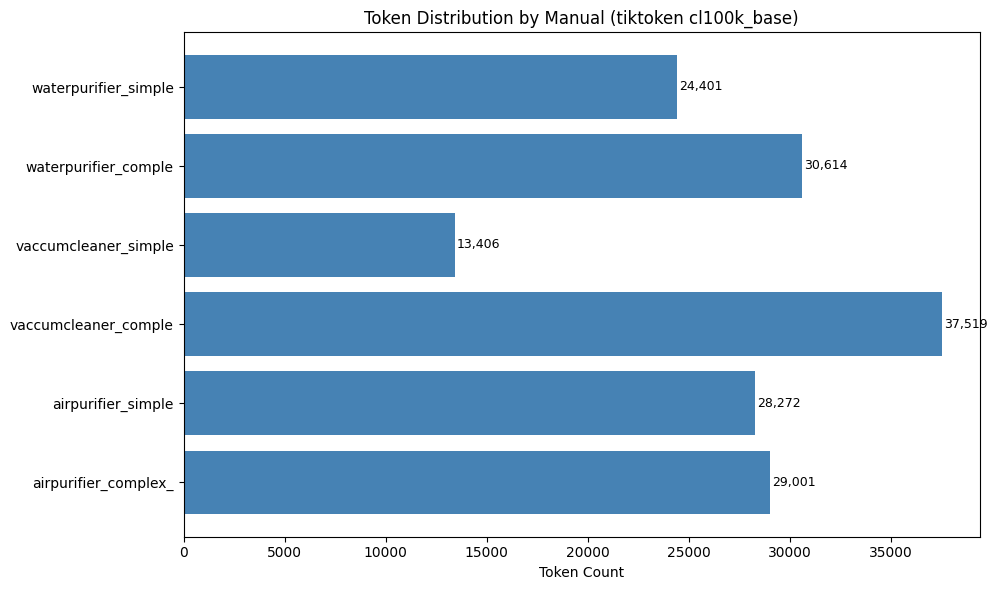

Saved: token_distribution.png


In [12]:
# Visualization
plt.figure(figsize=(10, 6))
bars = plt.barh(filenames, token_counts, color='steelblue')
plt.xlabel('Token Count')
plt.title('Token Distribution by Manual (tiktoken cl100k_base)')
plt.tight_layout()

# Add value labels
for bar, count in zip(bars, token_counts):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
             f'{count:,}', va='center', fontsize=9)

plt.savefig('token_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: token_distribution.png")

### §3.3.1 Chunk Size Distribution

In [13]:
# Get chunk sizes from vector store
all_docs = vectorstore._collection.get(include=['metadatas'])
chunk_sizes = [m.get('char_count', 0) for m in all_docs['metadatas']]

print(f"Chunk statistics (n={len(chunk_sizes)}):")
print(f"  Min: {min(chunk_sizes)}")
print(f"  Max: {max(chunk_sizes)}")
print(f"  Mean: {sum(chunk_sizes)/len(chunk_sizes):.0f}")
print(f"  Std: {(sum((x - sum(chunk_sizes)/len(chunk_sizes))**2 for x in chunk_sizes) / len(chunk_sizes))**0.5:.0f}")

Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


Chunk statistics (n=320):
  Min: 2
  Max: 1000
  Mean: 613
  Std: 298


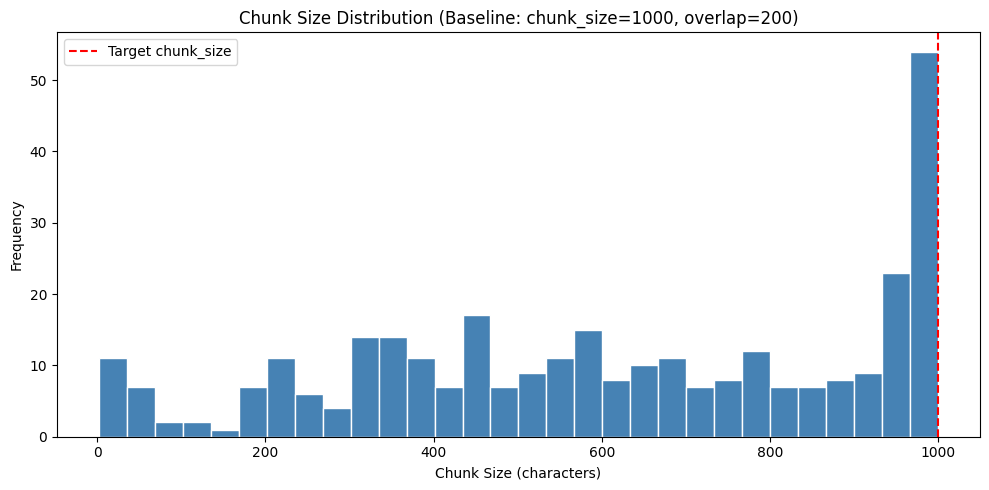

Saved: chunk_size_distribution.png


In [14]:
# Histogram
plt.figure(figsize=(10, 5))
plt.hist(chunk_sizes, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Chunk Size (characters)')
plt.ylabel('Frequency')
plt.title('Chunk Size Distribution (Baseline: chunk_size=1000, overlap=200)')
plt.axvline(x=1000, color='red', linestyle='--', label='Target chunk_size')
plt.legend()
plt.tight_layout()
plt.savefig('chunk_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chunk_size_distribution.png")

## §3.4 Summary Table: Noise Identification

| Noise Type | Frequency | Impact | Treatment |
|------------|-----------|--------|----------|
| Header (model name) | Every page | Medium | Regex removal |
| Page numbers | Every page | Low | Regex removal |
| Repeated safety warnings | Multiple pages | Medium | Deduplication |
| Broken table text | Tables | High | Layout-aware parsing |

## Notes

### Key Findings
1. **LIM-005 confirmed**: "정수기 필터 교체" query returns 2/5 wrong category (airpurifier)
   - Common terms ("필터", "교체") cause cross-category contamination
   - Fix: metadata filtering by category

2. **LIM-008 analyzed**: "청소기 배터리 충전 시간" query retrieves vacuum chunks
   - Chunks contain "충전" related words but no explicit duration
   - Either info not in docs, or text interleaving hides it

3. **Document structure**: All PDFs have tables (16-43), images vary (3-98)
   - Step patterns use numeric ("1 ", "2 ") not circled numbers

4. **Noise**: Repeated safety warnings, icon instructions appear multiple pages

### LIM-001 Quantification
- **79.4% of pages are multi-column** (200/252 pages)
- airpurifier_simple highest at 87.5%
- waterpurifier_complex lowest at 75.0%
- **This strongly supports C3 (layout-aware parsing) as main strategy**

### Token Distribution
- Total: 163,213 tokens across 6 PDFs
- Largest: vaccumcleaner_complex (37,519 tokens)
- Smallest: vaccumcleaner_simple (13,406 tokens)

### Chunk Statistics
- n=320 chunks, mean=613 chars, std=298
- Wide variance: min=2, max=1000

### Next Steps
- Proceed to chunking experiments (§4) with:
  - A (baseline): Recursive 1000/200
  - B1 (small): Recursive 500/100
  - B2 (large): Recursive 1500/300
  - C3 (layout-aware): unstructured/docling/marker — 2hr time box
  - C2 (custom sep): fallback if C3 fails